In [1]:
# PTB-XL ResNet1D Model (OSC Ready)

import os
import ast
import wfdb
import torch
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

In [5]:
# Dataset and Preprocessing

dataset_path = Path("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3")
ptbxl_path = dataset_path / "ptbxl_database.csv"
waveform_path = dataset_path

df = pd.read_csv(ptbxl_path)
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['scp_keys'] = df['scp_codes'].apply(lambda x: list(x.keys()))
target_labels = ['NORM', 'AFIB', 'PVC', 'LVH', 'IMI', 'ASMI', 'LAFB', 'IRBBB']
df['scp_filtered'] = df['scp_keys'].apply(lambda x: [k for k in x if k in target_labels])
df = df[df['scp_filtered'].map(len) > 0]
mlb = MultiLabelBinarizer(classes=target_labels)
y = mlb.fit_transform(df['scp_filtered'])
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

def load_ecg(record_path):
    record = wfdb.rdrecord(record_path)
    return record.p_signal  # shape: [5000, 12]

class PTBXL_Dataset(Dataset):
    def __init__(self, df, labels, base_dir):
        self.df = df
        self.labels = labels
        self.base_dir = base_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_path = os.path.join(self.base_dir, row['filename_lr'])
        signal = load_ecg(full_path).T  # now shape: [12, 5000]
        return torch.tensor(signal, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.float32)

train_dataset = PTBXL_Dataset(X_train, y_train, waveform_path)
test_dataset = PTBXL_Dataset(X_test, y_test, waveform_path)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=8, num_workers=2, pin_memory=True)

In [7]:
# ResNet1D Model Definition

class BasicBlock1d(nn.Module):
    expansion = 1
    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv1d(inplanes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(planes, planes, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(planes)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)

class ResNet1d(nn.Module):
    def __init__(self, block, layers, in_channels=12, num_classes=10):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv1d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(planes * block.expansion)
            )
        layers = [block(self.inplanes, planes, stride, downsample=downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x).squeeze(-1)
        return self.fc(x)


In [8]:
# Training and Evaluation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet1d(BasicBlock1d, [2, 2, 2, 2], in_channels=12, num_classes=len(target_labels)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100
losses, accuracies = [], []

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for signals, labels in train_loader_tqdm:
        signals, labels = signals.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        acc = (preds == labels).float().mean().item()
        correct += acc
        total += 1
        train_loader_tqdm.set_postfix(loss=loss.item())
    losses.append(total_loss / len(train_loader))
    accuracies.append(correct / total)
    print(f"Epoch {epoch+1}, Avg Loss: {losses[-1]:.4f}, Avg Accuracy: {accuracies[-1]:.4f}")



Epoch 1/100: 100%|██████████| 1788/1788 [00:50<00:00, 35.10it/s, loss=0.126] 


Epoch 1, Avg Loss: 0.2511, Avg Accuracy: 0.9014


Epoch 2/100: 100%|██████████| 1788/1788 [00:20<00:00, 87.92it/s, loss=0.18]  


Epoch 2, Avg Loss: 0.1908, Avg Accuracy: 0.9242


Epoch 3/100: 100%|██████████| 1788/1788 [00:19<00:00, 90.75it/s, loss=0.104] 


...

Epoch 98, Avg Loss: 0.0047, Avg Accuracy: 0.9982


Epoch 99/100: 100%|██████████| 1788/1788 [00:20<00:00, 87.34it/s, loss=0.00444] 


Epoch 99, Avg Loss: 0.0035, Avg Accuracy: 0.9989


Epoch 100/100: 100%|██████████| 1788/1788 [00:20<00:00, 87.41it/s, loss=0.000176]

Epoch 100, Avg Loss: 0.0036, Avg Accuracy: 0.9989


In [9]:
# Evaluation

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for signals, labels in test_loader:
        signals, labels = signals.to(device), labels.to(device)
        outputs = model(signals)
        y_true.append(labels.cpu().numpy())
        y_pred.append(torch.sigmoid(outputs).cpu().numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("Classification Report:")
print(classification_report(y_true > 0.5, y_pred > 0.5, target_names=mlb.classes_))
print("Macro ROC-AUC:", roc_auc_score(y_true, y_pred, average='macro'))

Classification Report:
              precision    recall  f1-score   support

        NORM       0.85      0.94      0.89      1878
        AFIB       0.87      0.92      0.89       298
         PVC       0.90      0.71      0.79       257
         LVH       0.76      0.53      0.62       409
         IMI       0.69      0.68      0.68       558
        ASMI       0.72      0.77      0.74       458
        LAFB       0.85      0.70      0.76       345
       IRBBB       0.69      0.67      0.68       233

   micro avg       0.80      0.80      0.80      4436
   macro avg       0.79      0.74      0.76      4436
weighted avg       0.80      0.80      0.80      4436
 samples avg       0.81      0.83      0.81      4436

Macro ROC-AUC: 0.9546645935439368


/users/PLS0150/shreeshtee/.conda/envs/acorn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
 # Helper function to compute macro-average ROC
def compute_macro_roc(y_true, y_pred):
    from sklearn.metrics import roc_curve, auc
    import numpy as np

    n_classes = y_true.shape[1]
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}

    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    return all_fpr, mean_tpr, macro_auc

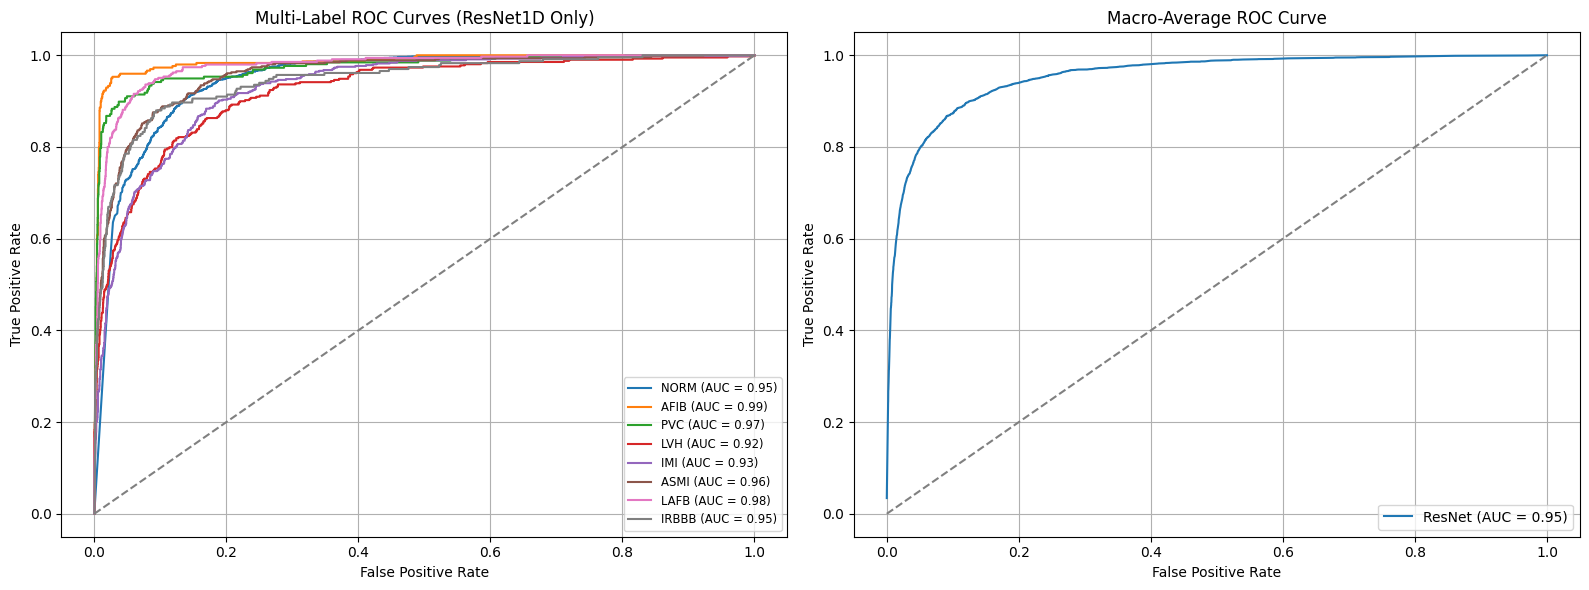

In [18]:
import matplotlib.pyplot as plt

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------- LEFT: Multi-label ROC ----------------
for i, label in enumerate(mlb.classes_):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Multi-Label ROC Curves (ResNet1D Only)')
axes[0].legend(loc='lower right', fontsize='small')
axes[0].grid(True)

# ---------------- RIGHT: Macro ROC ----------------
fpr, tpr, macro_auc = compute_macro_roc(y_true, y_pred)

axes[1].plot(fpr, tpr, label=f'ResNet (AUC = {macro_auc:.2f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('Macro-Average ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(True)

# Final layout
plt.tight_layout()
plt.show()

In [20]:
import numpy as np

# After evaluation
np.save("y_true_resnet.npy", y_true)
np.save("y_pred_resnet.npy", y_pred)
